<center> 

# DSSI: Summer 2025
    
## Math for Machine Learning - Calculus (Key)

#### Authored by: Bill Trok<center>


<center>
<img src="https://raw.githubusercontent.com/amandakube/Data118LectureImages/main/UChicago_DSI.png" alt="UC-DSI" width="300" height="100">
</center>

In [116]:
import torch

from torch import autograd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

## This Notebook

* Differential Calculus

## Functions

In machine learning we frequently have functions in the mathematical sense. In particular we typically have a **Loss Function** which measures how error prone our model is. Or we want might to maximize the accuracy of our model. For instance, below we have the familiar sine function.

In [118]:
torch.sin(torch.tensor([math.pi/4]))

tensor([0.7071])

In [119]:
# This is a tensor containing equally space values from 0 to 2 pi
a = torch.linspace(-math.pi/4, 2. * math.pi, steps=60)

In [120]:
b = torch.sin(a)
b

tensor([-7.0711e-01, -6.1752e-01, -5.1909e-01, -4.1321e-01, -3.0141e-01,
        -1.8529e-01, -6.6510e-02,  5.3222e-02,  1.7219e-01,  2.8869e-01,
         4.0105e-01,  5.0767e-01,  6.0700e-01,  6.9763e-01,  7.7826e-01,
         8.4773e-01,  9.0505e-01,  9.4940e-01,  9.8013e-01,  9.9681e-01,
         9.9920e-01,  9.8727e-01,  9.6118e-01,  9.2131e-01,  8.6824e-01,
         8.0271e-01,  7.2568e-01,  6.3824e-01,  5.4166e-01,  4.3731e-01,
         3.2669e-01,  2.1138e-01,  9.3048e-02, -2.6621e-02, -1.4591e-01,
        -2.6310e-01, -3.7653e-01, -4.8455e-01, -5.8563e-01, -6.7831e-01,
        -7.6127e-01, -8.3331e-01, -8.9341e-01, -9.4070e-01, -9.7450e-01,
        -9.9433e-01, -9.9991e-01, -9.9115e-01, -9.6818e-01, -9.3134e-01,
        -8.8114e-01, -8.1830e-01, -7.4374e-01, -6.5851e-01, -5.6384e-01,
        -4.6109e-01, -3.5173e-01, -2.3733e-01, -1.1952e-01,  1.7485e-07])

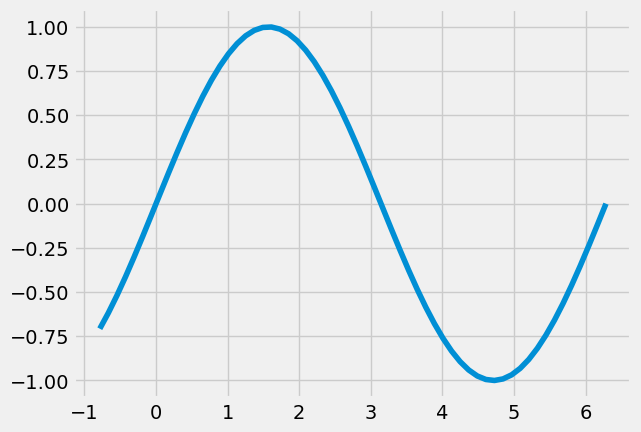

In [121]:
# graph the data
plt.plot(a,b)

## Derivatives and Slopes

Recall that the slope of a line between points $(x_1,y_1)$ and $(x_2,y_2)$ is given by 
$$ m = \frac{y_2 -y_1}{x_2-x_1}.$$

The derivative generalizes the concept of the slope to a general function, if $y = f(x)$, the derivative of $f(x)$ at $x = x_0$ is given by 
$$\lim_{h \to 0} \frac{f(x+h)-f(x)}{(x+h)-x} = \lim_{h \to 0} \frac{f(x+h)-f(x)}{h}.$$

In practice, with computers we estimate the value of a derivative by using a very small value of $h$. 


In [122]:
x1 = torch.tensor([0.5])
x2 = torch.tensor([0.5+0.00001])

#estimate the derivative of sin at x=0.5

(torch.sin(x2)-torch.sin(x1))/(x2-x1)

tensor([0.8750])

## Derivatives with Torch

In fact torch allows us to compute derivatives using the library ``autograd.grad``.

In [127]:

 
# Create a tensor x and set
# requires_grad=True to deal with derivatives
x = torch.tensor([0.5],requires_grad=True)
 
# Compute the derivative of f with respect to x
grad_sin = autograd.grad(torch.sin(x), x)[0]
 
# Print the derivative
print(grad_sin)

tensor([0.8776])


We can do this with any function we want, even ones we define ourselves.

In [129]:

 
# Define the function f
def f(x):
    return x**2+5*torch.sin(x)
 
# Create a tensor x and set
# requires_grad=True to deal with derivative
x = torch.tensor([0.0],requires_grad=True)
 
# Compute the gradient of f with respect to x
grad_f = autograd.grad(f(x), x)
 
# Print the gradient
print(grad_f)

(tensor([5.]),)


## Why do we care?

Derivatives are very useful when trying to optimize a function. For instance, suppose we have a model with a parameter $x$ and we want to find the value of $x$ that maximizes the accuracy of our model.

In [130]:
def acc_f(x):
    return torch.sigmoid(-x**2+0.1*x+5*torch.sin(x))

Text(0.5, 0, 'x')

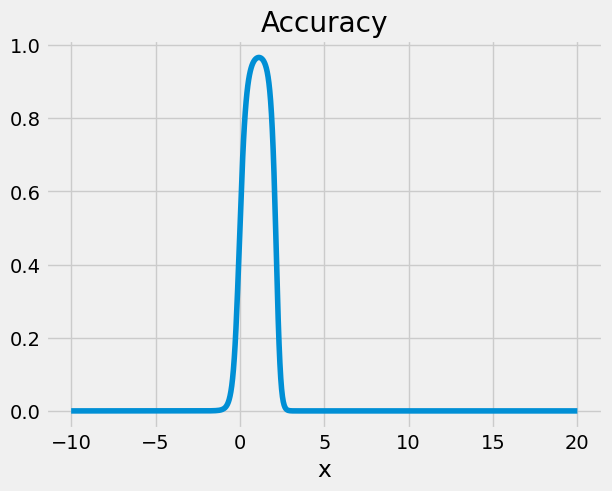

In [131]:
# This is a tensor containing equally space values from 0 to 2 pi
a = torch.linspace(-10, 20, steps=600)
b = acc_f(a)
plt.plot(a,b)
plt.title("Accuracy")
plt.xlabel("x")

## Gradient Ascent / Gradient Descent

Gradient Ascent is a method which allows us to find a $x$ value which makes a function $f(x)$ take on a relatively high value. The idea is that our derivative tells us in which direction a function is increasing. 

Gradient Descent, is the "opposite" method which allows us to find an $x$ value which makes $f(x)$ relatively small.

In [135]:
# This performs one instance of (unnormlized) gradient descent.
# Starting value, this is often choosen semi arbitrarily.
x0 = torch.tensor([0.0],requires_grad=True)
# Step_size "arbitrary" small value
step_size = 0.01

grad_acc = autograd.grad(acc_f(x0), x0)[0]
print(grad_acc)

x1 = x0 + grad_acc*step_size
print("x1 = ",x1)
print("f(x0)",acc_f(x0))
print("f(x1)",acc_f(x1))

tensor([1.2750])
x1 =  tensor([0.0127], grad_fn=<AddBackward0>)
f(x0) tensor([0.5000], grad_fn=<SigmoidBackward0>)
f(x1) tensor([0.5162], grad_fn=<SigmoidBackward0>)


In [144]:
# continue with another iteration of gradient ascent.
grad_acc = autograd.grad(acc_f(x1), [x1])[0]
print(grad_acc)

x2 = x1 + grad_acc*step_size
print(x2)

print("f(x1)",acc_f(x1))
print("f(x2)",acc_f(x2))

tensor([1.2672])
tensor([0.0254], grad_fn=<AddBackward0>)
f(x1) tensor([0.5162], grad_fn=<SigmoidBackward0>)
f(x2) tensor([0.5322], grad_fn=<SigmoidBackward0>)


To do many rounds we can implement this in a for loop.

In [141]:

xi = torch.tensor(0.0,requires_grad=True)
step_size = 0.01
for i in range(2000):
    grad_acc = autograd.grad(acc_f(xi), xi)[0]
    xi = xi + grad_acc*step_size
    
print("x_final = ",xi)
print("f(x_final) = ",acc_f(xi))

x_final =  tensor(1.1184, grad_fn=<AddBackward0>)
f(x_final) =  tensor(0.9664, grad_fn=<SigmoidBackward0>)


## Normalized Gradient Ascent
Usually it makes sense to normalize our gradient, that is divide by the norm. In this case the normalized gradient, is simply the direction of the increase but it doesn't remember how quickly the function is increasing in that direction. 

In [142]:
xi = torch.tensor(0.0,requires_grad=True)
step_size = 0.01
for i in range(200):
    grad_acc = autograd.grad(acc_f(xi), xi)[0]
    norm_grad = grad_acc/grad_acc.norm()
    #print(norm_grad)
    xi = xi + norm_grad*step_size
    
print("x_final = ",xi)
print("f(x_final) = ",acc_f(xi))

x_final =  tensor(1.1200, grad_fn=<AddBackward0>)
f(x_final) =  tensor(0.9664, grad_fn=<SigmoidBackward0>)


## Starting Values 

No matter the starting value (outside of rare cases), gradient ascent/descent will give a more optimal value of our function.

In [143]:
# Note the initial starting value can vary and we still get the same result in this case.
xi = torch.tensor(5.0,requires_grad=True)
step_size = 0.01
for i in range(1000):
    grad_acc = autograd.grad(acc_f(xi), xi)[0]
    norm_grad = grad_acc/grad_acc.norm()
    #print(norm_grad)
    xi = xi + norm_grad*step_size
    
print("x_final = ",xi)
print("f(x_final) = ",acc_f(xi))

x_final =  tensor(1.1200, grad_fn=<AddBackward0>)
f(x_final) =  tensor(0.9664, grad_fn=<SigmoidBackward0>)


Text(0.5, 0, 'x')

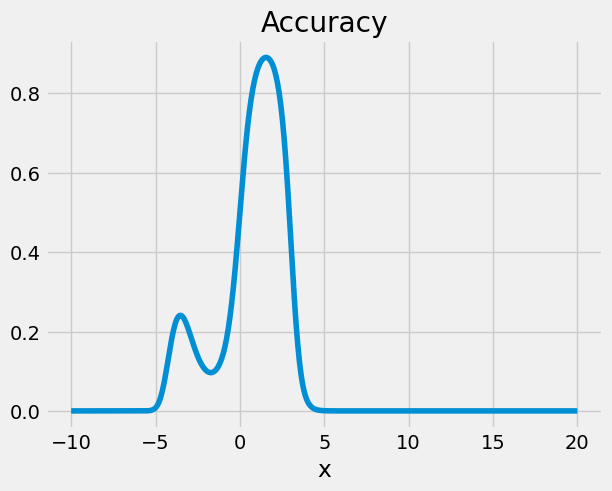

In [145]:
def acc_g(x):
    return torch.sigmoid(0.1*x+2*torch.sin(x)-0.01*x**4)

a = torch.linspace(-10, 20, steps=600)
b = acc_g(a)
plt.plot(a,b)
plt.title("Accuracy")
plt.xlabel("x")

In [149]:
# Try playing around with the starting points and see which values you can get.
xi = torch.tensor(0.0,requires_grad=True)
step_size = 0.01
for i in range(1000):
    grad_acc = autograd.grad(acc_g(xi), xi)[0]
    norm_grad = grad_acc/grad_acc.norm()
    #print(norm_grad)
    xi = xi + norm_grad*step_size
    
print("x_final = ",xi)
print("g(x_final) = ",acc_g(xi))

x_final =  tensor(1.5400, grad_fn=<AddBackward0>)
g(x_final) =  tensor(0.8906, grad_fn=<SigmoidBackward0>)


## Higher Dimensions


In higher dimensions, things get more complicated as there are multiple derivatives. Known as partial derivatives

$$f_x(x,y) = \lim_{h \to 0} \frac{f(x+h,y) - f(x,y)}{h}$$
$$f_y(x,y) = \lim_{h \to 0} \frac{f(x,y+h) - f(x,y)}{h}$$

However, there is a good stand in for the overall derivative, which is known as the **gradient**. This is the vector of first partial derivatives.

$$\nabla f(a,b) = \langle f_x(a,b),f_y(a,b) \rangle$$

We can again compute this via ``autograd.grad``.

In [150]:
def f(x,y):
    return 4*torch.exp(-x**2-y**2)+torch.exp(-(x-1)**2-(y+3)**2)


In [152]:
x=torch.tensor([0.5],requires_grad=True)
y=torch.tensor([1.0],requires_grad=True)
print("f(0.5,1.0) = ",f(x,y))
torch.tensor(autograd.grad(f(x,y), (x,y)))

f(0.5,1.0) =  tensor([1.1460], grad_fn=<AddBackward0>)


tensor([-1.1460, -2.2920])

This turns out to also have precise geometric meaning. Namely it points in the "uphill" direction, the direction where the function $f(x,y)$ is increasing the fastest. 

See Desmos demonstration.

In particular, this means we can use gradient descent/ascent in higher dimensions as well.

In [153]:
T = torch.tensor([0.5,1.0])
T[0]

tensor(0.5000)

In [156]:


xi = torch.tensor(0.5,requires_grad=True)
yi = torch.tensor(1.0,requires_grad=True)
step_size = 0.01
for i in range(2000):
    grad_acc = torch.tensor(autograd.grad(f(xi,yi), [xi,yi]))
    norm_grad = grad_acc/grad_acc.norm()
    #print(norm_grad)
    xi = xi + norm_grad[0]*step_size
    yi = yi + norm_grad[1]*step_size
print("xi = ",xi)
print("yi = ",yi)
print("f(xi,yi)=",f(xi,yi))
    

xi =  tensor(-0.0016, grad_fn=<AddBackward0>)
yi =  tensor(-0.0011, grad_fn=<AddBackward0>)
f(xi,yi)= tensor(4.0000, grad_fn=<AddBackward0>)


In this case it is often more convenient to carry this out by implementing multivariable functions as functions of a tensor.

In [157]:
def f(T):
    x = T[0]
    y = T[1]
    return 4*torch.exp(-x**2-y**2)+torch.exp(-(x-1)**2-(y+3)**2)

T = torch.tensor([0.5,1.0],requires_grad=True)
step_size = 0.01
for i in range(2000):
    grad_acc = autograd.grad(f(T), T)[0]
    norm_grad = grad_acc/grad_acc.norm()
    T = T + step_size*norm_grad
print("T = ",T)
print("f(T)=",f(T))


T =  tensor([-0.0016, -0.0011], grad_fn=<AddBackward0>)
f(T)= tensor(4.0000, grad_fn=<AddBackward0>)


## Gradient Descent

Other times we may want to minimize a function. For instance, we might have a "Loss Function" which is some measure of the amount of error a machine learning algorithm makes. In this case, we will want to minimize the function.

This process proceeds identically to Gradient Ascent expect that we move in the opposite direction, towards $-\nabla f(x,y)$ instead of $\nabla f(x,y)$.

## Activity

## Exercise 1

Consider the function $f(x) = -6 x^2 - x^3 + x^4$. Implement Gradient Descent to find the minimum value of this function.

HINT: Note you may have to be careful with your choice of starting value.

In [168]:
# code here
def f(x):
    return -6 *x**2-x**3+x**4

xi = torch.tensor(1.0,requires_grad=True)
step_size = 0.01
for i in range(1000):
    grad_acc = autograd.grad(f(xi), xi)[0]
    norm_grad = grad_acc/grad_acc.norm()
    #print(norm_grad)
    xi = xi - norm_grad*step_size
print("xi",xi)
print("f(xi)",f(xi))

xi tensor(2.1400, grad_fn=<SubBackward0>)
f(xi) tensor(-16.3052, grad_fn=<AddBackward0>)


## Exercise 2

Following up on exercise 1. Graph the function, based on the shape of the graph which starting values for gradient descent do you think will eventually end up converging to the minimum value?

Text(0.5, 0, 'x')

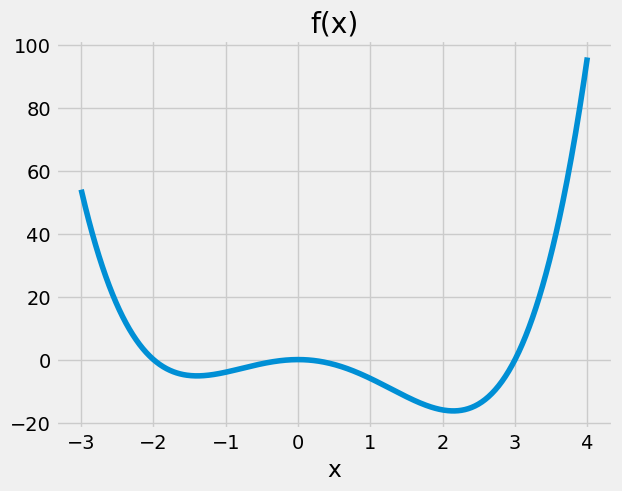

In [163]:


a = torch.linspace(-3, 4, steps=600)
b = f(a)
plt.plot(a,b)
plt.title("f(x)")
plt.xlabel("x")

## Exercise 3

Performing gradient descent on the function $f(x) = x^3+x$. Use a step size of $0.01$, and starting point of $-0.5$. Perform 1000 iterations, then 2000 iterations, then 3000 iterations. What do you notice?

Graph the function and explain this behavior.

NOTE: This behavior is actually quite common in practice in machine learning. 

Text(0.5, 0, 'x')

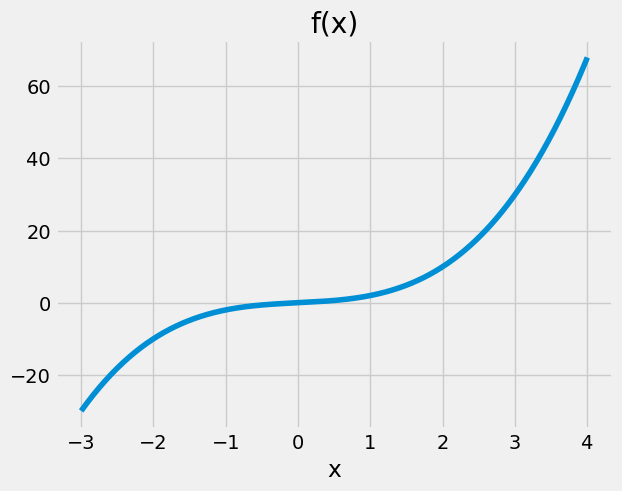

In [170]:
# code here
def f(x):
    return x**3+x

a = torch.linspace(-3, 4, steps=600)
b = f(a)
plt.plot(a,b)
plt.title("f(x)")
plt.xlabel("x")

In [174]:


xi = torch.tensor(0.5,requires_grad=True)
step_size = 0.01
for i in range(3000):
    grad_acc = autograd.grad(f(xi), xi)[0]
    norm_grad = grad_acc/grad_acc.norm()
    #print(norm_grad)
    xi = xi - norm_grad*step_size
print("xi",xi)
print("f(xi)",f(xi))

xi tensor(-29.5006, grad_fn=<SubBackward0>)
f(xi) tensor(-25703.3906, grad_fn=<AddBackward0>)
